# Tutorial 6: Mixed Precision Quantization Search with Mase and Optuna

In this tutorial, we'll see how Mase can be integrated with Optuna, the popular hyperparameter optimization framework, to search for a Bert model optimized for sequence classification on the IMDb dataset. We'll take the Optuna-generated model and import it into Mase, then run the CompressionPipeline to prepare the model for edge deployment by quantizing and pruning its weights.

As we'll see, running Architecture Search with Mase/Optuna involves the following steps.

1. **Define the search space**: this is a dictionary containing the range of values for each parameter at each layer in the model.

2. **Write the model constructor**: this is a function which uses Optuna utilities to sample a model from the search space, and constructs the model using transformers from_config class method.

3. **Write the objective function**: this function calls on the model constructor defined in Step 2 and defines the training/evaluation setup for each search iteration.

4. **Go!** Choose an Optuna sampler, create a study and launch the search.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can load the Bert checkpoint directly from HuggingFace.

In [47]:
from transformers import AutoModel

model = AutoModel.from_pretrained(checkpoint)

If you have previously ran the tutorial on Neural Architecture Search (NAS), run the following cell to import the best model obtained from the search process.

In [48]:
from pathlib import Path
import dill

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "rb") as f:
    base_model = dill.load(f)

First, fetch the dataset using the `get_tokenized_dataset` utility.

In [49]:
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


## 1. Defining the Search Space

We'll start by defining a search space, i.e. enumerating the possible combinations of hyperparameters that Optuna can choose during search. We'll explore the following range of values for the model's hidden size, intermediate size, number of layers and number of heads.

In [50]:
import torch
from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatDenorm,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    # LinearBlockMinifloat, # removed as not fully implemented
    LinearBlockLog,
    LinearBinary,
    LinearBinaryScaling,
    LinearBinaryResidualSign, 
)

## 2. Writing a Model Constructor

We define the following function, which will get called in each iteration of the search process. The function is passed the `trial` argument, which is an Optuna object that comes with many functionalities - see the [Trial documentation](https://optuna.readthedocs.io/en/stable/reference/trial.html) for more details. Here, we use the `trial.suggest_categorical` function, which triggers the chosen sampler to choose a layer type. The suggested integer is the index into the search space for each parameter, which we defined in the previous cell.

In [51]:
from chop.tools.utils import deepsetattr
from copy import deepcopy


def construct_model(trial, sp):
    search_space = sp
    
    linear_layer_type_mapping = {
        "Linear": torch.nn.Linear,
        "LinearInteger": LinearInteger,
        "LinearMinifloatDenorm": LinearMinifloatDenorm,
        "LinearMinifloatIEEE": LinearMinifloatIEEE,
        "LinearLog": LinearLog,
        "LinearBlockFP": LinearBlockFP,
        # "LinearBlockMinifloat": LinearBlockMinifloat,
        "LinearBlockLog": LinearBlockLog,
        "LinearBinary": LinearBinary,
        "LinearBinaryScaling": LinearBinaryScaling,
        "LinearBinaryResidualSign": LinearBinaryResidualSign
    }

    # Fetch the model
    trial_model = deepcopy(base_model)

    # Quantize layers according to optuna suggestions
    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            layer_cls_name = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )
            layer_cls = linear_layer_type_mapping[layer_cls_name]

            if layer_cls == torch.nn.Linear:
                continue

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
            }

            # Group layer types by argument similarities
            integer_type_layers = {LinearInteger}
            float_type_layers = {LinearMinifloatDenorm, LinearMinifloatIEEE, LinearBlockFP} #, LinearBlockMinifloat}
            log_type_layers = {LinearLog, LinearBlockLog}
            binary_type_layers = {LinearBinary, LinearBinaryScaling, LinearBinaryResidualSign}
            block_layers = {LinearBlockFP, LinearBlockLog} #, LinearBlockMinifloat}
            
            if layer_cls in integer_type_layers:
                width = trial.suggest_categorical(f"{name}_width", search_space["layer_widths"])
                frac_width = trial.suggest_categorical(f"{name}_frac_width", search_space["layer_frac_widths"])
            
                kwargs["config"] = {
                    "data_in_width": width, "data_in_frac_width": frac_width,
                    "weight_width": width, "weight_frac_width": frac_width,
                    "bias_width": width, "bias_frac_width": frac_width,
                }
                
            elif layer_cls in float_type_layers:
                width = trial.suggest_categorical(f"{name}_width", search_space["layer_widths"])
                exp_width = trial.suggest_categorical(f"{name}_exponent_width", search_space["layer_exp_widths"])
                
                kwargs["config"] = {
                    "data_in_width": width, "data_in_exponent_width": exp_width, "data_in_exponent_bias": None,
                    "weight_width": width, "weight_exponent_width": exp_width, "weight_exponent_bias": None,
                    "bias_width": width, "bias_exponent_width": exp_width, "bias_exponent_bias": None,
                }
                
                # if layer_cls == LinearBlockMinifloat:
                #     exponent_bias_width = width-1-exp_width
                #     # exponent_bias_width = trial.suggest_categorical(f"{name}_block_size", search_space["layer_block_sizes"])                    
                #     kwargs["config"].update({"weight_exponent_bias_width": exponent_bias_width, "bias_exponent_bias_width": exponent_bias_width, "data_in_exponent_bias_width": exponent_bias_width})
                if layer_cls in block_layers:
                    block_size = trial.suggest_categorical(f"{name}_block_size", search_space["layer_block_sizes"])
                    
                    kwargs["config"].update({
                        "data_in_block_size": block_size, "weight_block_size": block_size, "bias_block_size": block_size
                    })
                    
            elif layer_cls in log_type_layers:
                width = trial.suggest_categorical(f"{name}_layer_width", search_space["layer_widths"])
                
                kwargs["config"] = {
                    "data_in_width": width, "data_in_exponent_bias": None,
                    "weight_width": width, "weight_exponent_bias": None,
                    "bias_width": width, "bias_exponent_bias": None,
                }
                if layer_cls in block_layers:
                    block_size = trial.suggest_categorical(f"{name}_block_size", search_space["layer_block_sizes"])
                    exp_bias_width = trial.suggest_categorical(f"{name}_exponent_bias_width", search_space["layer_exp_bias_widths"])
                    
                    kwargs["config"].update({
                        "data_in_block_size": block_size, "weight_block_size": block_size, "bias_block_size": block_size,
                        "data_in_exponent_bias_width": exp_bias_width, "weight_exponent_bias_width": exp_bias_width, "bias_exponent_bias_width": exp_bias_width
                    })
                    
            elif layer_cls in binary_type_layers:
                kwargs["config"] = {
                    "binary_training": True,
                    "data_in_stochastic": trial.suggest_categorical(f"{name}_data_in_stochastic", [True, False]),
                    "weight_stochastic": trial.suggest_categorical(f"{name}_weight_stochastic", [True, False]),
                    "bias_stochastic": trial.suggest_categorical(f"{name}_bias_stochastic", [True, False]),
                    "data_in_bipolar": True,
                    "weight_bipolar": True,
                    "bias_bipolar": True,
                }
            else:
                raise NotImplementedError

            # Create the new layer (copy the weights)
            layer = layer_cls(**kwargs)
            layer.weight.data = layer.weight.data

            # Replace the layer in the model
            deepsetattr(trial_model, name, layer)

    return trial_model

## 3. Defining the Objective Function

Next, we define the objective function for the search, which gets called on each trial. In each trial, we create a new model instace with chosen hyperparameters according to the defined sampler. We then use the `get_trainer` utility in Mase to run a training loop on the IMDb dataset for a number of epochs. Finally, we use `evaluate` to report back the classification accuracy on the test split.

In [52]:
from chop.tools import get_trainer
import random


def objective(trial, sp):
    '''
    trial: optuna trial object
    sp: search space
    '''

    # Define the model
    model = construct_model(trial, sp)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

## 4. Launching the Search

Optuna provides a number of samplers, for example:

* **GridSampler**: iterates through every possible combination of hyperparameters in the search space
* **RandomSampler**: chooses a random combination of hyperparameters in each iteration
* **TPESampler**: uses Tree-structured Parzen Estimator algorithm to choose hyperparameter values.

You can define the chosen sampler by simply importing from `optuna.samplers` as below.

In [53]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

# sampler = RandomSampler()
sampler = TPESampler()

With all the pieces in place, we can launch the search as follows. The number of trials is set to 1 so you can go get a coffee for 10 minutes, then proceed with the tutorial. However, this will essentially be a random model - for better results, set this to 100 and leave it running overnight!

In [54]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=0,
    timeout=60 * 60 * 24,
)

[I 2025-02-11 12:02:17,090] A new study created in memory with name: bert-tiny-nas-study


# Task 1

In [2]:
import optuna
import dill
from pathlib import Path

# Helpers
def save_pyobject(obj, name):
    with open(f"{Path.home()}/tutorial_6_{name}.pkl", "wb") as f:
        dill.dump(obj, f)

def get_best_accuracy_each_trial(study):
    """
    Returns a list of the maximum accuracy observed up to each trial.
    For trial i, we look at all completed trials up to i, find the best value.
    """
    bests = []
    current_best = float('-inf')
    for i, t in enumerate(study.trials):
        if t.value is not None and t.value > current_best:
            current_best = t.value
        bests.append(current_best)
    return bests

def save_best_trial(study, name):
    best_trial = study.best_trial
    best_trial.user_attrs["model"] = best_trial.user_attrs["model"].cpu()
    
    with open(f"{Path.home()}/tutorial_6_best_trial_{name}", "wb") as f:
        dill.dump(best_trial, f)

def save_pyobject(obj, name):
    with open(f"{Path.home()}/tutorial_6_{name}.pkl", "wb") as f:
        dill.dump(obj, f)

def load_pyobject(path):
    with open(f"{Path.home()}/{path}", "rb") as f:
        return dill.load(f)

/rds/general/user/hn621/home/miniforge3/envs/mase/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from functools import partial

linear_layer_types = [
    "LinearInteger",
    "LinearMinifloatDenorm",
    "LinearMinifloatIEEE",
    "LinearLog",
    "LinearBlockFP",
    # "LinearBlockMinifloat",
    "LinearBlockLog",
    "LinearBinary",
    "LinearBinaryScaling",
    "LinearBinaryResidualSign"
]

layer_widths = [8, 16, 32]
layer_frac_widths = [2, 4, 8]
layer_exp_widths = [2, 4, 8]
layer_exp_bias_widths = [2, 4, 8]
layer_block_sizes = [[8], [16], [32]]

def get_mp_search_space(i):
    print(str(linear_layer_types[i]))

    search_space = {
        "linear_layer_choices": [
            "Linear",
            linear_layer_types[i]
        ],
        "layer_widths": layer_widths,
        "layer_frac_widths": layer_frac_widths,
        "layer_exp_widths": layer_exp_widths,
        "layer_exp_bias_widths": layer_exp_bias_widths,
        "layer_block_sizes": layer_block_sizes,
    }
    
    return search_space, linear_layer_types[i]
    
def run_study(sampler, sp, n_trials=50, study_name="test_study"):
    study = optuna.create_study(
        direction="maximize",
        study_name=study_name,
        sampler=sampler,
    )

    study.optimize(
        partial(objective, sp=sp),
        n_trials=n_trials,
        timeout=60 * 60 * 24,
    )

    return study

## Experiments

In [57]:
def run_experiment(i, n_trials=80):
    search_space, precision = get_mp_search_space(i)
    study = run_study(sampler, search_space, n_trials=n_trials, study_name=precision)

    # save best accuracies and best model
    bests = get_best_accuracy_each_trial(study)
    save_pyobject(bests, f"best_accuracies_{i}_{precision}")
    save_best_trial(study, precision)

    return bests

def test_construct(i):
    run_experiment(i, n_trials=1)

In [58]:
# acc_bests = {}

# # integer-type layers (0)
# run_experiment(0)

In [59]:
# # other type layers
# for i in range(1, 9):
#     run_experiment(i)

In [ ]:
# other type layers
for i in range(5, 9):
    run_experiment(i)

## Plot

In [4]:
# load best accuracies from disk
acc_bests = {}
for i in range(0, 9):
    acc_bests[i] = load_pyobject(f"tutorial_6_best_accuracies_{i}_{linear_layer_types[i]}.pkl")

/var/tmp/pbs.186413.pbs-7/ipykernel_443098/1900534147.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(linear_layer_types))


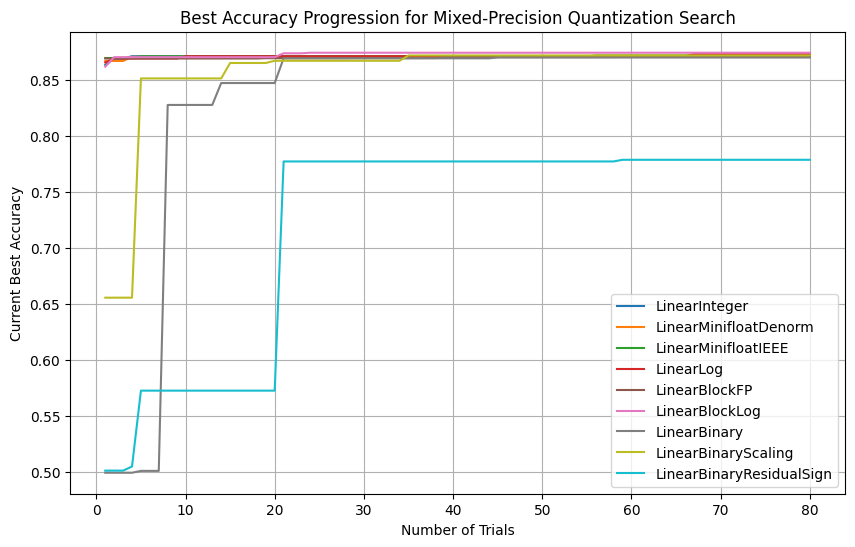

In [19]:
import matplotlib.pyplot as plt

# Assign line styles based on quantization type
line_styles = {
    "Integer": ":",
    "Minifloat": "--",
    "Log": "-.",
    "BlockFP": "--",
    "Binary": "-"
}

# Define color map
colors = plt.cm.get_cmap("tab10", len(linear_layer_types))

plt.figure(figsize=(10, 6))

# Plot each type
for idx, layer in enumerate(linear_layer_types):
    trials = list(range(1, 81)) # list(range(1, len(acc_bests[idx]) + 1))
    acc_values = acc_bests[idx][:80]

    # # Determine line style based on type
    # if "Integer" in layer:
    #     style = line_styles["Integer"]
    # elif "Minifloat" in layer:
    #     style = line_styles["Minifloat"]
    # elif "Log" in layer or "BlockLog" in layer:
    #     style = line_styles["Log"]
    # elif "Binary" in layer:
    #     style = line_styles["Binary"]
    # else:
    #     style = "-"  # Default

    style = "-"  # Default

    plt.plot(trials, acc_values, style, label=layer, color=colors(idx))

plt.xlabel("Number of Trials")
plt.ylabel("Current Best Accuracy")
plt.title("Best Accuracy Progression for Mixed-Precision Quantization Search")
plt.legend()
plt.grid(True)
plt.savefig("imgs/tut6_mpqs.png")
plt.show()

/var/tmp/pbs.186413.pbs-7/ipykernel_443098/2830108848.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(linear_layer_types))


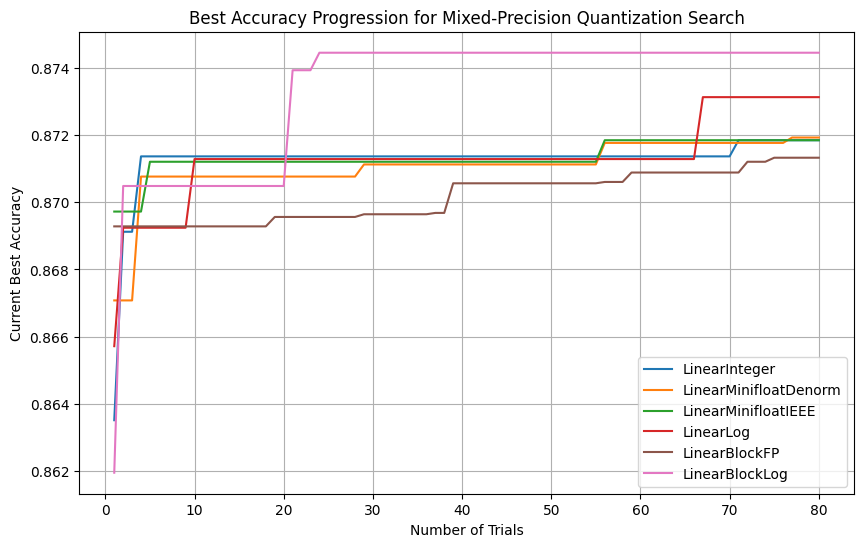

In [20]:
import matplotlib.pyplot as plt

# Assign line styles based on quantization type
line_styles = {
    "Integer": "-",
    "Minifloat": "--",
    "Log": "-.",
    "BlockFP": "--",
    "Binary": ":"
}

# Define color map
colors = plt.cm.get_cmap("tab10", len(linear_layer_types))

plt.figure(figsize=(10, 6))

# Plot each type
for idx, layer in enumerate(linear_layer_types[0:6]):
    trials = list(range(1, 81)) # list(range(1, len(acc_bests[idx]) + 1))
    acc_values = acc_bests[idx][:80]

    # # Determine line style based on type
    # if "Integer" in layer:
    #     style = line_styles["Integer"]
    # elif "Minifloat" in layer:
    #     style = line_styles["Minifloat"]
    # elif "Log" in layer or "BlockLog" in layer:
    #     style = line_styles["Log"]
    # elif "Binary" in layer:
    #     style = line_styles["Binary"]
    # else:
    #     style = "-"  # Default
    style = "-"  # Default

    plt.plot(trials, acc_values, style, label=layer, color=colors(idx))

plt.xlabel("Number of Trials")
plt.ylabel("Current Best Accuracy")
plt.title("Best Accuracy Progression for Mixed-Precision Quantization Search")
plt.legend()
plt.grid(True)
plt.savefig("imgs/tut6_mpqs_zoomed.png")
plt.show()

In [14]:
# with open(f"{Path.home()}/tutorial_6_best_model_LinearBinaryScaling", "rb") as f:
#     file = dill.load(f)

In [1]:
# print(file)